# Setup

In [2]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [40]:
from rich import print
from tpvalidator.workspace import TriggerActivityWorkspace

import mplhep as hep
import matplotlib.pyplot as plt

# Data

In [9]:
taws = TriggerActivityWorkspace('../../../radbkg_5000.root', 'taFinder')


Key 'mctruths' not found in file.


In [15]:
taws.ta_win_cluster_stats.sadc

entry  subentry
0      0             795
       1            7024
       2           12769
       3            2467
       4            9650
                   ...  
4999   914          3590
       915          6765
       916          8097
       917          9998
       918          6930
Name: sadc, Length: 4639579, dtype: uint32

In [70]:
simulated_readout_time_s = len(taws.event_summary)*8500*0.5e-6
num_crps = 28
num_crps_fdvd = 160

print(f"Simulated time in seconds {simulated_readout_time_s}")

crtp_time = simulated_readout_time_s*num_crps
print(f"Simulated crtp_time time in seconds {crtp_time}")

fdvd_time = simulated_readout_time_s*num_crps/num_crps_fdvd
print(f"Simulated fdvd10k time in seconds {fdvd_time}")




Simulated time in seconds 21.25

Simulated crtp_time time in seconds 595.0

Simulated fdvd10k time in seconds 3.71875

WeightedSum(value=1.07563, variance=0.289245) 21265.0

WeightedSum(value=0.806723, variance=0.216934) 21275.0

Text(0.5, 0.5, '1 Hz threshold (21265.0-21275.0)')

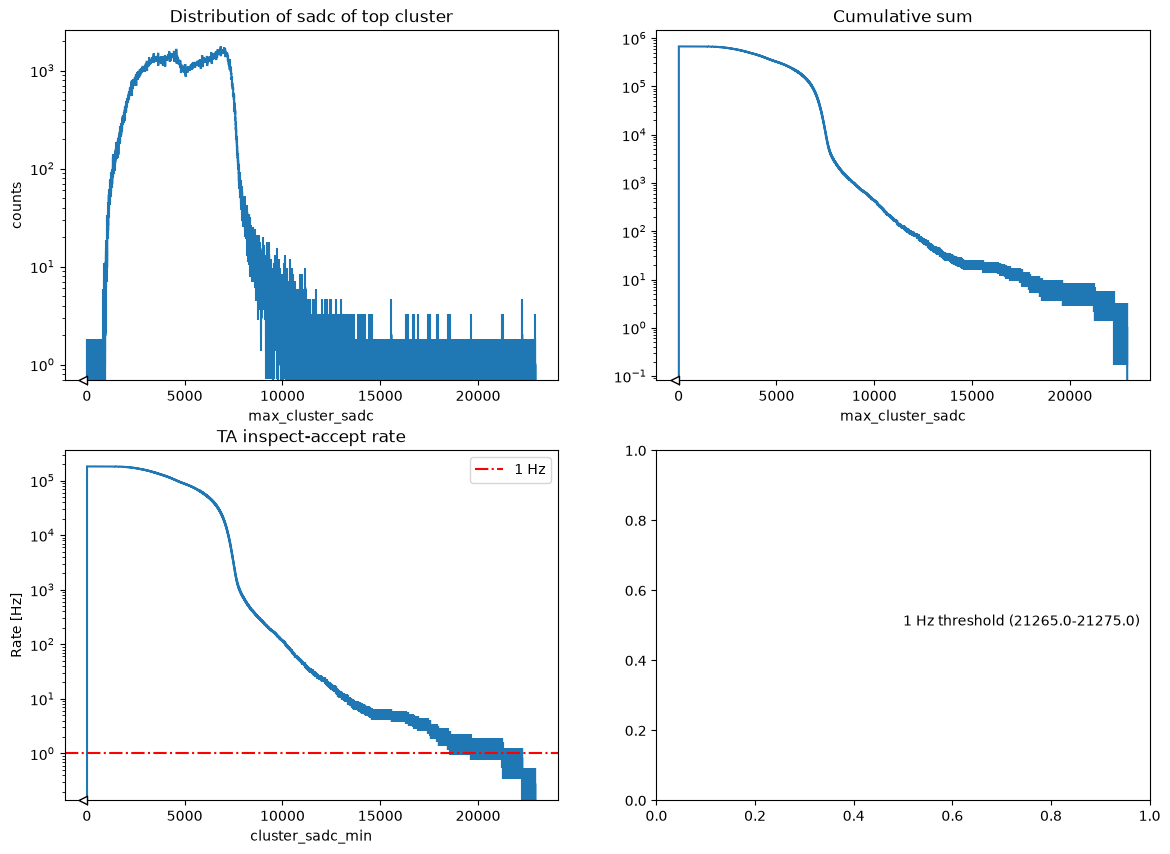

In [109]:
from tpvalidator.analysis.histograms import make_regaxis, build_histogram, cumsum_hist_nd

cl_sadc_axis = make_regaxis(taws.ta_win_cluster_stats, 'max_cluster_sadc', 10)

h = build_histogram(taws.ta_win_cluster_stats, [
    cl_sadc_axis
])


# Plot the sum adc of the top cluster in all inspect windows
fig, axes = plt.subplots(2, 2, figsize=(14,10))
ax = axes[0][0]
hep.histplot(h[1:], ax=ax)
ax.set_title('Distribution of sadc of top cluster')
ax.set_ylabel('counts')
ax.set_yscale('log')

# Plot the right-to-left cumulative sum
ax = axes[0][1]
ch = cumsum_hist_nd(h[1:], 0, 'right')
hep.histplot(ch, ax=ax)
ax.set_title('Cumulative sum')
ax.set_yscale('log')


ax = axes[1][0]

rh = (
    # Cumuative sum histogram
    ch / fdvd_time
)

hep.histplot(rh, ax=ax)
ax.set_title('TA inspect-accept rate')
ax.set_yscale('log')
ax.set_ylabel('Rate [Hz]')
ax.set_xlabel('cluster_sadc_min')

ax.axhline(1, label='1 Hz', c='red', ls='-.')
ax.legend()



target_rate = 1.

nb = len(rh.axes[0])

for i in range(nb-1, 0, -1):
    if rh[i].value > target_rate:
        print(rh[i], rh.axes[0].centers[i])
        print(rh[i+1], rh.axes[0].centers[i+1])

        thres_left = rh.axes[0].centers[i]
        thres_right = rh.axes[0].centers[i+1]
        break


ax = axes[1][1]

ax.text(0.5, 0.5, f'1 Hz threshold ({thres_left}-{thres_right})')

WeightedSum(value=1.07563, variance=0.289245) 21265.0

WeightedSum(value=0.806723, variance=0.216934) 21275.0